# 🧩 Neurociência do TEA: da triagem comportamental à conectividade cerebral

O **Transtorno do Espectro Autista (TEA)** é uma condição do neurodesenvolvimento caracterizada por
diferenças na comunicação social e por padrões restritos/repetitivos de comportamento. Do ponto de
vista **neurocientífico**, as principais linhas de evidência apontam para:

- **Teoria da sub-conectividade** (Just et al., 2004): comunicação reduzida entre regiões corticais
  distantes (fronto-posteriores), com possível *hiper*-conectividade local.
- **Desequilíbrio excitação/inibição** (Rubenstein & Merzenich, 2003): alteração do balanço
  glutamato/GABA em microcircuitos corticais.
- **Substância branca**: estudos de **DTI** (imagem por tensor de difusão) mostram reduções de
  **anisotropia fracional (FA)** em tratos como o **corpo caloso**, sugerindo alterações na
  integridade/organização dos axônios que conectam os hemisférios.

Este notebook explora o TEA em **duas escalas**, com dois datasets públicos:

| Parte | Escala | Dataset | O que medimos |
|---|---|---|---|
| **A** | Comportamental | Autism Screening Adult (AQ-10, UCI) | Respostas ao questionário de triagem |
| **B** | Neurobiológica | ABIDE II — subset NYU processado (DTI) | Conectividade estrutural + FA/MD por trato |

> ⚠️ **Nota ética**: instrumentos de triagem **não são diagnóstico**. O diagnóstico de TEA é
> clínico e multidisciplinar. Modelos treinados aqui têm finalidade exclusivamente didática.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 1.2,
})
COR_TEA, COR_CTRL = "#D55E00", "#0072B2"   # paleta colorblind-safe (Okabe-Ito)
np.random.seed(42)

# ── Localiza os dados: no Kaggle ficam em /kaggle/input; localmente via kagglehub ──
if Path("/kaggle/input").exists():
    bases = list(Path("/kaggle/input").iterdir())
else:
    import kagglehub
    bases = [Path(kagglehub.dataset_download("faizunnabi/autism-screening")),
             Path(kagglehub.dataset_download("jodyam/abide-ii-processed-nyu-subset"))]

ARFF = next(p for b in bases for p in b.rglob("Autism_Data.arff"))
ABIDE = next(p for b in bases for p in b.rglob("IDs_with_class.csv")).parent
print("Screening:", ARFF)
print("ABIDE II :", ABIDE)

Screening: /Users/leonardonunes/.cache/kagglehub/datasets/faizunnabi/autism-screening/versions/1/Autism_Data.arff
ABIDE II : /Users/leonardonunes/.cache/kagglehub/datasets/jodyam/abide-ii-processed-nyu-subset/versions/1/ToKaggle


---
# Parte A — Triagem comportamental (AQ-10)

O **AQ-10** (Autism Spectrum Quotient, versão curta; Allison et al., 2012) tem 10 itens sobre
percepção de detalhes, alternância de atenção, comunicação e **teoria da mente** (inferir estados
mentais alheios). Cada item vale 0 ou 1 ponto; **escore ≥ 6** indica encaminhamento para avaliação.

O dataset (704 adultos, UCI) traz as 10 respostas pontuadas, dados demográficos e a classe de triagem.

In [2]:
# O arquivo tem extensão .arff mas o conteúdo é CSV com cabeçalho
scr = pd.read_csv(ARFF, quotechar="'", na_values="?", skip_blank_lines=True)
scr.columns = [c.strip() for c in scr.columns]
scr = scr[scr["age"] < 100].copy()            # remove 1 idade impossível (383)
scr["classe"] = (scr["Class/ASD"].str.upper() == "YES").astype(int)
scr["escore"] = scr[[f"A{i}_Score" for i in range(1, 11)]].sum(axis=1)

print(f"{len(scr)} participantes | triagem positiva: {scr['classe'].mean():.1%}")
scr[["age", "gender", "escore", "Class/ASD"]].head()

701 participantes | triagem positiva: 27.0%


,age,gender,escore,Class/ASD
0,26.0,f,6,NO
1,24.0,m,5,NO
2,27.0,m,8,YES
3,35.0,f,6,NO
4,40.0,f,2,NO


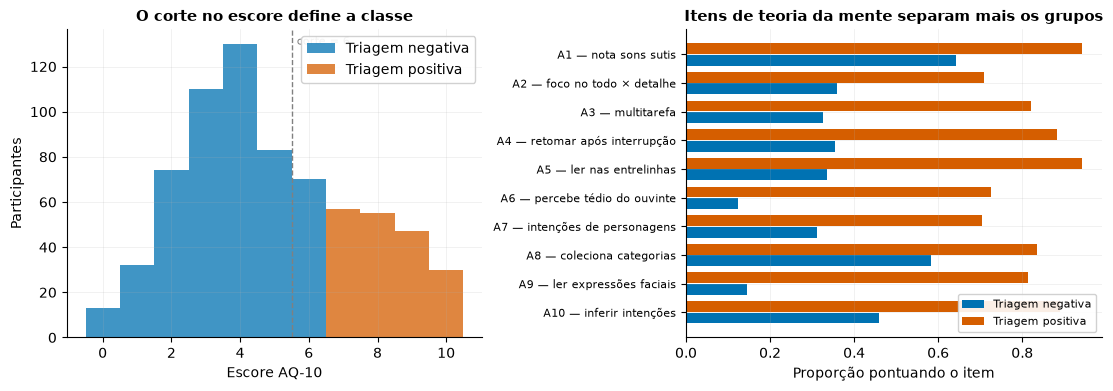

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

# Distribuição do escore AQ-10 por classe
for val, cor, nome in [(0, COR_CTRL, "Triagem negativa"), (1, COR_TEA, "Triagem positiva")]:
    axes[0].hist(scr.loc[scr["classe"] == val, "escore"], bins=np.arange(-0.5, 11.5),
                 alpha=0.75, color=cor, label=nome)
axes[0].axvline(5.5, color="gray", ls="--", lw=1)
axes[0].text(5.65, axes[0].get_ylim()[1] * 0.95, "corte = 6", color="gray", fontsize=8)
axes[0].set_xlabel("Escore AQ-10"); axes[0].set_ylabel("Participantes")
axes[0].set_title("O corte no escore define a classe")
axes[0].legend(framealpha=0.9)

# Proporção de resposta pontuada por item, por classe
ITENS = {1: "nota sons sutis", 2: "foco no todo × detalhe", 3: "multitarefa",
         4: "retomar após interrupção", 5: "ler nas entrelinhas", 6: "percebe tédio do ouvinte",
         7: "intenções de personagens", 8: "coleciona categorias", 9: "ler expressões faciais",
         10: "inferir intenções"}
props = scr.groupby("classe")[[f"A{i}_Score" for i in range(1, 11)]].mean()
ypos = np.arange(10)
axes[1].barh(ypos + 0.2, props.loc[0], height=0.38, color=COR_CTRL, label="Triagem negativa")
axes[1].barh(ypos - 0.2, props.loc[1], height=0.38, color=COR_TEA, label="Triagem positiva")
axes[1].set_yticks(ypos, [f"A{i} — {ITENS[i]}" for i in range(1, 11)], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Proporção pontuando o item")
axes[1].set_title("Itens de teoria da mente separam mais os grupos")
axes[1].legend(framealpha=0.9, fontsize=8);

### Um classificador... bom demais para ser verdade

Treinar um modelo para prever a classe a partir dos itens parece natural — mas neste dataset a
classe **é derivada do próprio escore** (soma dos itens ≥ 6). Isso é **vazamento de rótulo
(label leakage)**: o modelo apenas redescobre a regra de corte. Vamos demonstrar.

Acurácia (5-fold): 100.0% ± 0.0%  ← esperado: quase perfeita


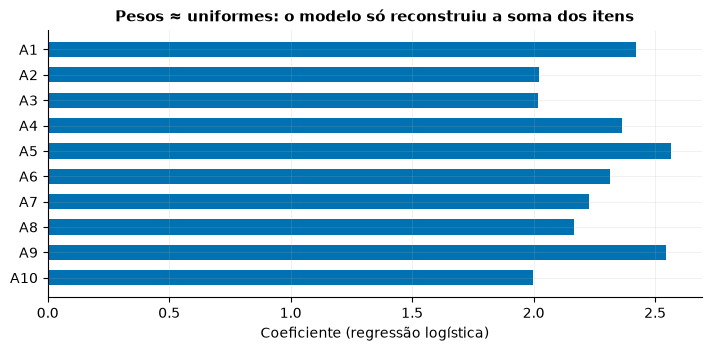

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_itens = scr[[f"A{i}_Score" for i in range(1, 11)]]
logit = LogisticRegression(max_iter=1000)
acc = cross_val_score(logit, X_itens, scr["classe"], cv=5, scoring="accuracy")
print(f"Acurácia (5-fold): {acc.mean():.1%} ± {acc.std():.1%}  ← esperado: quase perfeita")

logit.fit(X_itens, scr["classe"])
pesos = pd.Series(logit.coef_[0], index=[f"A{i}" for i in range(1, 11)])
fig, ax = plt.subplots(figsize=(7, 3.4), constrained_layout=True)
ax.barh(pesos.index[::-1], pesos.values[::-1], color=COR_CTRL, height=0.6)
ax.set_title("Pesos ≈ uniformes: o modelo só reconstruiu a soma dos itens")
ax.set_xlabel("Coeficiente (regressão logística)");

**Lição de metodologia** (ecoando a W1D1 da Neuromatch: *o que* o modelo responde?): acurácia de
~100% aqui não diz nada sobre detectar TEA — diz apenas que o rótulo é função determinística das
features. Para ciência de verdade, precisamos de um alvo **independente** das features: é o que
temos na Parte B, em que o rótulo é o **diagnóstico clínico** e as features vêm do **cérebro**.

---
# Parte B — Conectividade cerebral (ABIDE II, DTI)

O **ABIDE** (Autism Brain Imaging Data Exchange) agrega neuroimagem de milhares de participantes.
Usamos um subset processado do sítio NYU: **55 sujeitos** (33 TEA, 22 controles — convenção ABIDE:
grupo 1 = TEA), cada um com:

- **Matriz de conectividade estrutural 50×50** entre tratos de substância branca (atlas JHU ICBM-DTI-81);
- **Métricas escalares de DTI** por trato: **FA** (anisotropia fracional — organização das fibras),
  **MD** (difusividade média), AD e RD.

In [5]:
ids = pd.read_csv(ABIDE / "IDs_with_class.csv")
ids["grupo"] = ids["Class"].map({1: "TEA", 2: "Controle"})
# mantém apenas sujeitos cuja pasta de dados existe no dataset
ids = ids[ids["SUB_ID"].astype(str).map(lambda s: (ABIDE / s).exists())].reset_index(drop=True)
print(ids["grupo"].value_counts().to_dict())

conn, fa = {}, {}
for _, linha in ids.iterrows():
    sid = str(linha["SUB_ID"])
    cm = pd.read_csv(ABIDE / sid / f"Connectivity Matrix-{sid}.csv", index_col=0)
    conn[sid] = cm.to_numpy(dtype=float)
    sm = pd.read_csv(ABIDE / sid / f"{sid}_scalar_metrics.csv")
    fa[sid] = sm.set_index("RegionName")["FA"]

regioes = list(cm.columns)
FA = pd.DataFrame(fa).T.loc[ids["SUB_ID"].astype(str)]   # sujeitos × 50 tratos
FA["grupo"] = ids["grupo"].to_numpy()
print(f"Matrizes: {len(conn)} sujeitos × {conn[sid].shape} | FA: {FA.shape}")

{'TEA': 31, 'Controle': 22}
Matrizes: 53 sujeitos × (50, 50) | FA: (53, 51)


### FA por trato: onde a microestrutura difere?

Comparamos a FA média de cada trato entre grupos (teste *t* de Welch) e corrigimos os 50 testes
por **FDR** (Benjamini-Hochberg) — em amostras pequenas, a correção costuma "matar" efeitos, e
mostrar isso é parte da honestidade estatística.

Tratos com p<0.05 sem correção: 1 | após FDR: 0


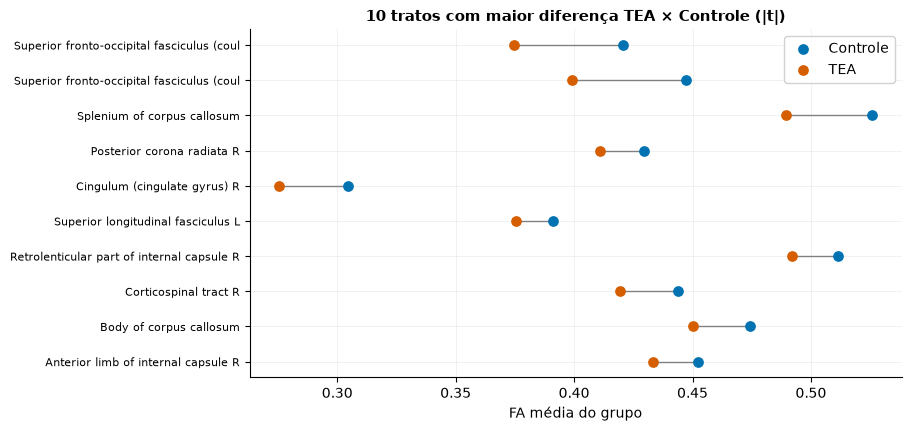

In [6]:
from statsmodels.stats.multitest import multipletests

fa_tea = FA[FA["grupo"] == "TEA"].drop(columns="grupo")
fa_ctl = FA[FA["grupo"] == "Controle"].drop(columns="grupo")
t, p = stats.ttest_ind(fa_tea, fa_ctl, equal_var=False)
rej, p_fdr, *_ = multipletests(p, alpha=0.05, method="fdr_bh")

res = (pd.DataFrame({"trato": fa_tea.columns, "t": t, "p": p, "p_fdr": p_fdr,
                     "FA_TEA": fa_tea.mean(), "FA_Controle": fa_ctl.mean()})
       .assign(abs_t=lambda d: d["t"].abs()).sort_values("abs_t", ascending=False))
print(f"Tratos com p<0.05 sem correção: {(res['p'] < 0.05).sum()} | após FDR: {rej.sum()}")

top = res.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
ypos = np.arange(len(top))
ax.scatter(top["FA_Controle"], ypos, color=COR_CTRL, s=45, label="Controle", zorder=3)
ax.scatter(top["FA_TEA"], ypos, color=COR_TEA, s=45, label="TEA", zorder=3)
for i, (_, r) in enumerate(top.iterrows()):
    ax.plot([r["FA_TEA"], r["FA_Controle"]], [i, i], color="gray", lw=1, zorder=2)
ax.set_yticks(ypos, [tr[:42] for tr in top["trato"]], fontsize=8)
ax.set_xlabel("FA média do grupo")
ax.set_title("10 tratos com maior diferença TEA × Controle (|t|)")
ax.legend(framealpha=0.9);

### Matrizes de conectividade: média por grupo e diferença

Heatmaps da conectividade média (escala sequencial, raiz quarta para comprimir a cauda) e a
**matriz de diferença** (TEA − Controle) em escala divergente com o zero em neutro.

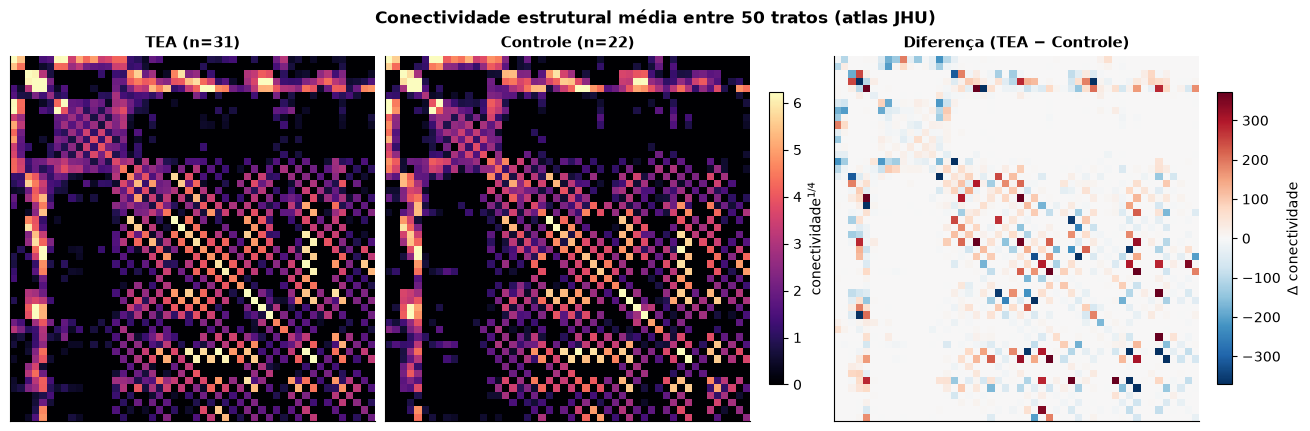

In [7]:
mask_tea = (ids["grupo"] == "TEA").to_numpy()
stack = np.stack([conn[str(s)] for s in ids["SUB_ID"]])
media_tea, media_ctl = stack[mask_tea].mean(0), stack[~mask_tea].mean(0)
dif = media_tea - media_ctl

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
vmax = np.percentile(np.stack([media_tea, media_ctl]) ** 0.25, 99)
for ax, M, titulo in [(axes[0], media_tea, f"TEA (n={mask_tea.sum()})"),
                      (axes[1], media_ctl, f"Controle (n={(~mask_tea).sum()})")]:
    im = ax.imshow(M ** 0.25, cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(titulo); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=axes[1], label="conectividade$^{1/4}$", shrink=0.8)

lim = np.percentile(np.abs(dif), 99)
im2 = axes[2].imshow(dif, cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[2].set_title("Diferença (TEA − Controle)")
axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].grid(False)
fig.colorbar(im2, ax=axes[2], label="Δ conectividade", shrink=0.8)
fig.suptitle("Conectividade estrutural média entre 50 tratos (atlas JHU)", fontweight="bold");

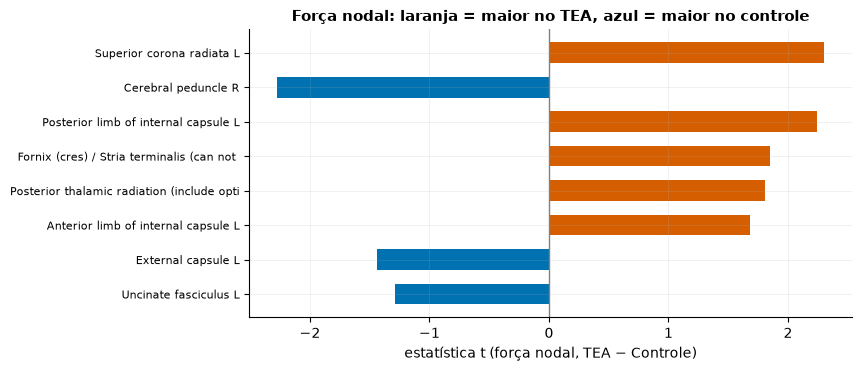

In [8]:
# Força nodal: soma das conexões de cada trato — a versão "grafo" da pergunta
forca = stack.sum(axis=2)                       # sujeitos × 50
ft, fp = stats.ttest_ind(forca[mask_tea], forca[~mask_tea], equal_var=False)
nodal = (pd.DataFrame({"trato": regioes, "t": ft, "p": fp})
         .assign(abs_t=lambda d: d["t"].abs()).sort_values("abs_t", ascending=False))
top_n = nodal.head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.5, 3.6), constrained_layout=True)
cores = [COR_TEA if v > 0 else COR_CTRL for v in top_n["t"]]
ax.barh([tr[:42] for tr in top_n["trato"]], top_n["t"], color=cores, height=0.6)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("estatística t (força nodal, TEA − Controle)")
ax.set_title("Força nodal: laranja = maior no TEA, azul = maior no controle")
ax.tick_params(axis="y", labelsize=8);

### O cérebro prevê o diagnóstico? (o teste honesto)

Agora sim um problema legítimo: **features cerebrais** (triângulo superior da matriz de
conectividade + FA) → **diagnóstico clínico**. Com n=55, usamos validação cruzada estratificada e
um pipeline com padronização + PCA para não estourar a dimensionalidade (1.225 pares + 50 FAs).

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score

iu = np.triu_indices(50, k=1)
X_cerebro = np.hstack([np.stack([conn[str(s)][iu] for s in ids["SUB_ID"]]),
                       FA.drop(columns="grupo").to_numpy()])
y_dx = (ids["grupo"] == "TEA").astype(int).to_numpy()

pipe = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=15, random_state=42)),
                 ("clf", LogisticRegression(max_iter=2000))])
cv = StratifiedKFold(5, shuffle=True, random_state=42)
bacc = cross_val_score(pipe, X_cerebro, y_dx, cv=cv, scoring="balanced_accuracy")
print(f"Acurácia balanceada (5-fold): {bacc.mean():.1%} ± {bacc.std():.1%}")
print(f"Chance = 50% | literatura ABIDE (n≈1000): ~65–70%")

Acurácia balanceada (5-fold): 41.4% ± 14.8%
Chance = 50% | literatura ABIDE (n≈1000): ~65–70%


---
# Conclusões

| | Parte A (AQ-10) | Parte B (ABIDE II / DTI) |
|---|---|---|
| Alvo | derivado das próprias features (leakage) | diagnóstico clínico independente |
| Acurácia | ~100% — **ilusória** | modesta — **real** |
| Lição | valide a origem do rótulo | neuroimagem de TEA é sinal fraco + n pequeno |

- O TEA não tem um "marcador" único: os efeitos de conectividade são **distribuídos e sutis**,
  coerentes com a teoria da sub-conectividade — e exigem amostras grandes (por isso o ABIDE agrega sítios).
- O contraste entre as partes A e B é a maior lição de método do notebook: **desempenho alto com
  rótulo contaminado vale menos que desempenho modesto com rótulo legítimo**.

### Para continuar
- **ABIDE completo** via `nilearn.datasets.fetch_abide_pcp` (fMRI funcional, n>1000)
- **BCIAUT-P300** (Kaggle): EEG de interface cérebro-computador para reabilitação em TEA
- **Eye-tracking autism** (Kaggle): atipicidades de olhar — um dos biomarcadores mais robustos
- Curso aberto **Neuromatch Academy** (compneuro.neuromatch.io): W1D1 (tipos de modelo), W2D2 (sinais)

### Referências
- Just et al. (2004). *Cortical activation and synchronization during sentence comprehension in
  high-functioning autism.* Brain.
- Rubenstein & Merzenich (2003). *Model of autism: increased ratio of excitation/inhibition.* Genes Brain Behav.
- Allison et al. (2012). *Toward brief "red flags" for autism screening (AQ-10).* JAACAP.
- Di Martino et al. (2017). *Enhancing studies of the connectome in autism (ABIDE II).* Sci Data.